In [1]:
import numpy as np
import bayesflow as bf
from pathlib import Path

from benchmark.examples.diffusion.simulators.rdm_4 import RDM


INFO:bayesflow:Using backend 'tensorflow'


In [2]:
np.random.seed(2026)

In [3]:
simulators = [
    RDM(model="m0", keep_params=False),
    RDM(model="m1", keep_params=False),
    RDM(model="m2", keep_params=False),
    RDM(model="m3", keep_params=False),
]

In [4]:
# Each trial contains signed RT and condition: (batch_size, 384, 2).
adapter = (
    bf.adapters.Adapter()
    .as_set(["rt", "conditions"])
    .concatenate(["rt", "conditions"], into="summary_variables")
    .convert_dtype("float64", "float32")
    .rename("model_indices", "inference_variables")
)

In [5]:
workflow = bf.ModelComparisonWorkflow(
    simulator=simulators,
    adapter=adapter,
    summary_network=bf.networks.DeepSet(summary_dim=12),
    scoring_rules="logistic",
    model_names=["M0", "M1", "M2", "M3"],
    initial_learning_rate=1e-3,
)


In [6]:
val_data = workflow.simulate(1000)

In [7]:
history = workflow.fit_online(epochs=200, num_batches_per_epoch=64, batch_size=256, validation_data=val_data)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 71s 889ms/step - ScoringRuleNetwork/scoring_rule: 2.0502 - loss: 2.0502 - val_ScoringRuleNetwork/scoring_rule: 1.9566 - val_loss: 1.9566
Epoch 2/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 59s 914ms/step - ScoringRuleNetwork/scoring_rule: 1.5527 - loss: 1.5527 - val_ScoringRuleNetwork/scoring_rule: 1.2513 - val_loss: 1.2513
Epoch 3/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 56s 880ms/step - ScoringRuleNetwork/scoring_rule: 1.1838 - loss: 1.1838 - val_ScoringRuleNetwork/scoring_rule: 1.1470 - val_loss: 1.1470
Epoch 4/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 55s 857ms/step - ScoringRuleNetwork/scoring_rule: 1.1063 - loss: 1.1063 - val_ScoringRuleNetwork/scoring_rule: 1.0163 - val_loss: 1.0163
Epoch 5/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 61s 963ms/step - ScoringRuleNetwork/scoring_rule: 0.9988 - loss: 0.9988 - val_ScoringRuleNetwork/scoring_rule: 0.9954 - val_loss: 0.9954
Epoch 6/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 60s 932ms/step - ScoringRuleNetwork/scoring_rule: 0.9970 - loss: 0.9970 - val_Sco

INFO:bayesflow:Training completed in 3.17 hours.


Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Estimating completed in 2.16 seconds.


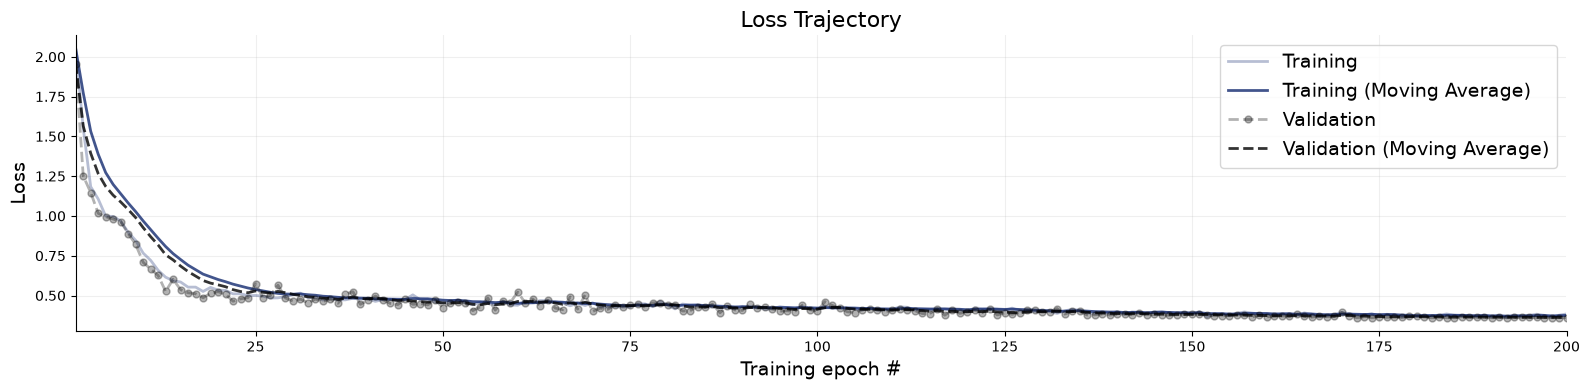

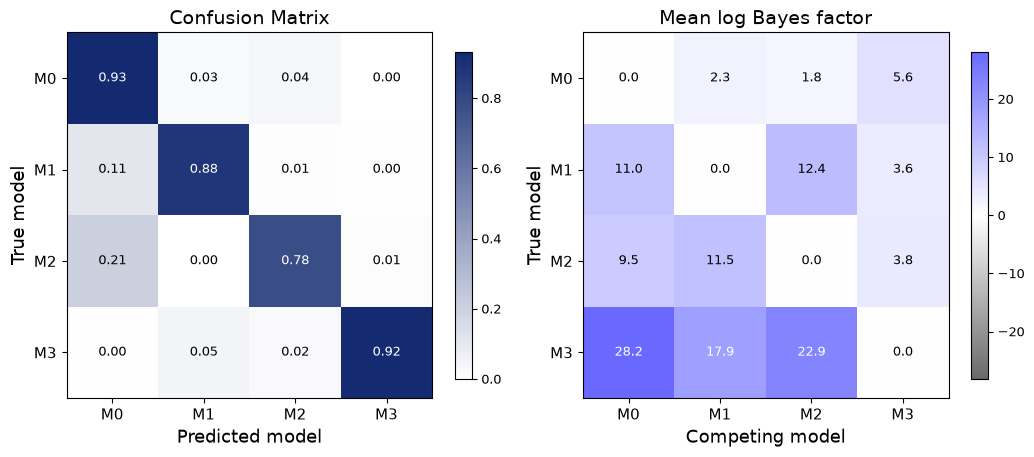

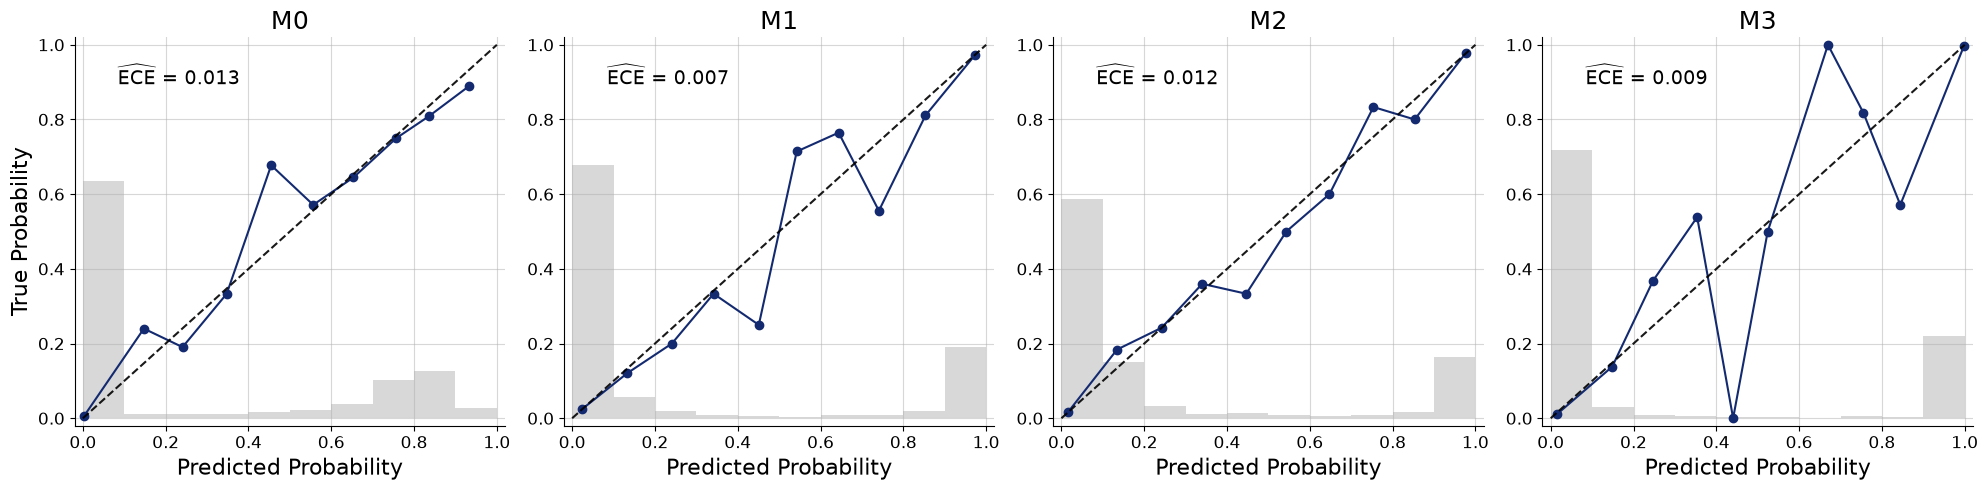

In [8]:
figures = workflow.plot_default_diagnostics(test_data=2000)

In [9]:
# Save the trained approximator
filepath = Path("/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/approximators/trained/direct/direct_logistic.keras")
filepath.parent.mkdir(exist_ok=True)
workflow.approximator.save(filepath=filepath)


In [10]:
# Evaluate the saved checkpoint on the shared indirect benchmark.
from benchmark.examples.diffusion.analysis.direct_calibration import ensure_direct_pmp_thresholds
from benchmark.examples.diffusion.analysis.direct_diagnostics import ensure_direct_diagnostics

LOSS = "logistic"
thresholds = ensure_direct_pmp_thresholds(LOSS, checkpoint=filepath)
diagnostics = ensure_direct_diagnostics(LOSS, checkpoint=filepath, indirect_tag="S4D")
print(f"Saved {len(thresholds)} threshold rows and {len(diagnostics)} observed diagnostic rows.")
print(filepath.parent.parent / "results" / "direct" / f"direct_{LOSS}")


Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Calibrated logistic on 400 saved diffusion datasets: /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/direct/direct_logistic/calibration/thresholds.csv


Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Fitting direct_logistic/m0 against the persisted shared raw reference bank


...

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.
INFO:absl:Epoch 1/250
 1/16 ━━━━━━━━━━━━━━━━━━━━ 1:59 8s/step - loss: 17.0273
 4/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 11.3548
 7/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 8.2193 
10/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 4.6197
13/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2.1598
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 7.1673

INFO:absl:Epoch 2/250
 1/16 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 1.5712
 4/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.9284
 8/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2355
12/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: -1.1941
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: -0.6398
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0335 

INFO:absl:Epoch 3/250
 1/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: -1.1172
 5/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: -1.3246
 8/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: -1.

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Saved 2176 observed diagnostic rows for logistic
Saved 4 threshold rows and 2176 observed diagnostic rows.
/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/approximators/trained/results/direct/direct_logistic
